In [1]:
import dnois
from dnois.optics import rt
import matplotlib.pyplot as plt
import numpy as np
import torch

import conf
import apparaturs
import sim
import utils

In [2]:
torch.set_grad_enabled(False)
utils.overwrite_dnois_ray_march()

In [3]:
in_mode = 0  #0:TE,1:TM
out_mode = 0  #0:TE,1:TM

In [4]:
rcwa_k, rcwa_t = utils.load_rcwa_data('../data/RCWA/0617-17point2d')
rcwa_k = rcwa_k[0]  #(17,169,6)
rcwa_t = rcwa_t[0]  #(17,169,2,2)

In [5]:
# for i in range(17):
#     _, ax = utils.vis_direction(rcwa_k[i, :, :3], (13, 13))
#     ax.view_init(90, -90)
utils.vis_direction(rcwa_k[0, :, :3], (13, 13))

In [6]:
complex_t = rcwa_t[..., in_mode, out_mode]  #(17,169)
transmittance = np.abs(complex_t)
phase_shift = np.angle(complex_t)

out_d = rcwa_k[..., in_mode * 3:in_mode * 3 + 3]  #(17,169,3)

In [20]:
resolution = 256
image_width = 0.1e-3
sensor = dnois.sensor.Sensor(resolution, image_width / resolution)

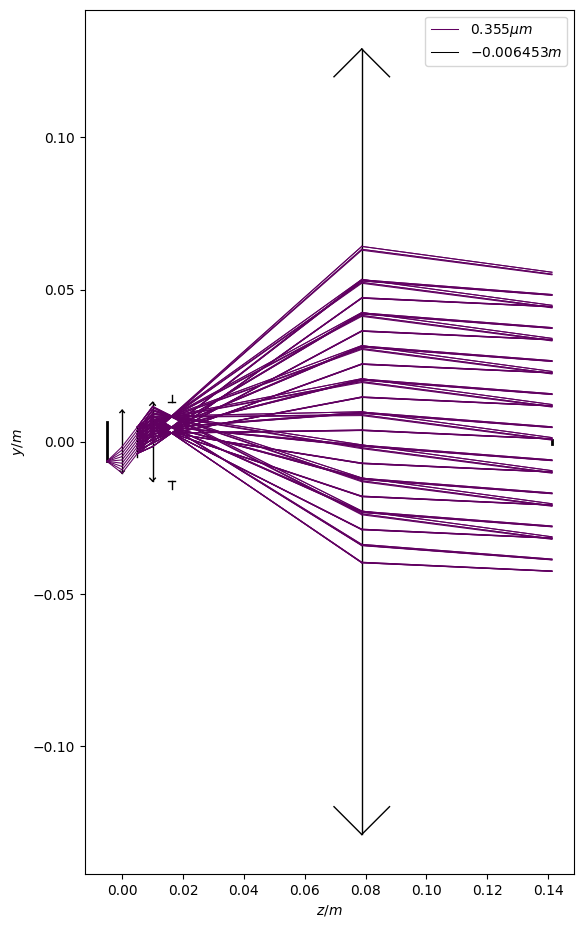

In [12]:
def vis_cross_section(point_idx: int = 0):
    sq = apparaturs.layout_fixed_0701(transmittance[[point_idx]], phase_shift[[point_idx]], out_d[[point_idx]])
    optics = rt.CoaxialRayTracing(sq, sensor, wl=conf.wl, depth=sq.first.fl1).double()

    radius = sq[3].apt.radius * conf.sigma
    points = sim.make_17_points(-optics.depth.squeeze().item(), radius)
    points[..., :2] = -points[..., :2]
    optics.plot_cross_section(height=points[point_idx, 1], init_rays=20)


vis_cross_section(11)

# 成像模拟
## 单点

In [21]:
def sim_single_point(point_idx: int = 0):
    sq = apparaturs.layout_fixed_0701(transmittance[[point_idx]], phase_shift[[point_idx]], out_d[[point_idx]])
    optics = rt.CoaxialRayTracing(sq, sensor, wl=conf.wl, depth=sq.first.fl1).double()

    radius = sq[3].apt.radius * conf.sigma
    point = sim.make_17_points(-optics.depth.squeeze().item(), radius).unsqueeze(1).unsqueeze(1)  #(N_s,1,1,3)
    point = point.to(dtype=optics.dtype)
    point = point[[point_idx]]
    irradiance = sim.irradiance_from_point(optics, point, 128)

    fig, ax = plt.subplots()
    im = ax.imshow(irradiance.cpu().numpy())
    # ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax)

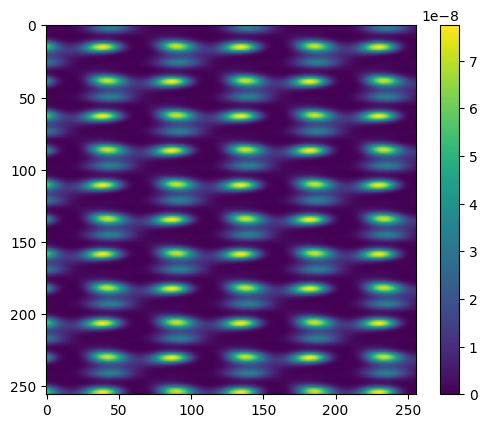

In [25]:
sim_single_point(9)

## 面光源

In [26]:
def sim_17_point():
    sq = apparaturs.layout_fixed_0701(transmittance, phase_shift, out_d)
    optics = rt.CoaxialRayTracing(sq, sensor, wl=conf.wl, depth=sq.first.fl1).double()

    radius = sq[3].apt.radius * conf.sigma
    point = sim.make_17_points(-optics.depth.squeeze().item(), radius).unsqueeze(1).unsqueeze(1)  #(N_s,1,1,3)
    point = point.to(dtype=optics.dtype)
    irradiance = sim.irradiance_from_point(optics, point, 128)

    fig, ax = plt.subplots()
    im = ax.imshow(irradiance.cpu().numpy())
    # ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax)

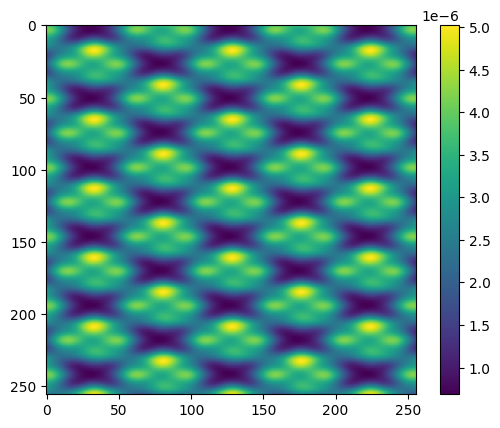

In [27]:
sim_17_point()